# Notebook 04 — Morphing Shape Modes

> **Supplementary §6**

With whole-body rotation removed, the marker data now contains only intrinsic wing and tail morphing. This notebook runs PCA on the **unilateral** (single-side) data to extract the morphing shape modes — a compact set of variables that describe how hawks change their wing and tail shape during flight.

## Contents
1. [Setup and data loading](#setup)
2. [Separating left and right sides](#separating-left-and-right)
3. [Running unilateral PCA](#running-unilateral-pca)
4. [Variance explained](#variance-explained)
5. [Loadings and component interpretation (preview)](#loadings-and-component-interpretation)
6. [Cross-bird consistency (preview)](#cross-bird-consistency)
7. [Score traces over a flight (preview)](#score-traces)
8. [Reconstructing flight shapes](#reconstructing-flight-shapes)

In [1]:
# --- Setup ---
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format='retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

plt.rcParams['font.family'] = 'Andale Mono'
np.set_printoptions(suppress=True, precision=3)

from morphing_birds import Animal3D, plot_plotly, animate_plotly, animate_plotly_compare

from kinematic_morphospace import (
    filter_by, run_PCA, run_PCA_birds,
    get_score_df, get_score_range, get_binned_scores,
    reconstruct, to_bilateral, to_unilateral,
)
from kinematic_morphospace.plotting import (
    plot_explained, plot_components_grid,
    plot_score_multi_PCs, compare_coeffs_hawks,
    plot_hist_similar_shapes,
    save_figure,
)
# Set True to reproduce exact manuscript iteration counts (slower)
PAPER_MODE = False

## Load Rotation-Corrected Data

We load the transformed (rotation-corrected) markers from Notebook 03.

In [2]:
# Load rotation-corrected markers and metadata
transformed_markers = np.load("../../data/bilateral/rotation_corrected_markers.npy")
combined_frame_info_df = pd.read_csv("../../data/bilateral/frame_info.csv")

print(f"Transformed markers shape: {transformed_markers.shape}")
print(f"Frames: {len(combined_frame_info_df):,}")

Transformed markers shape: (144764, 9, 3)
Frames: 144,764


## Separating Left and Right Sides

We separate the left and right markers and mirror the left side across the x-axis so that both sides share the same coordinate frame. This allows PCA to capture side-specific morphing patterns and improves sensitivity to asymmetric motions.

The unilateral data has **4 markers × 3 coordinates = 12 features** per side per frame. Left and right frames are stacked, effectively doubling the sample size while halving the dimensionality.

**Marker order (per side):** wingtip, primary, secondary, tailtip.

In [3]:
# Separate left and right markers, mirror left, and stack to create unilateral data
# Marker indices: 0=left_wingtip, 1=right_wingtip, 2=left_primary, 3=right_primary,
#                 4=left_secondary, 5=right_secondary, 6=left_tailtip, 7=right_tailtip
# Tailpack is index 8 (excluded)

unilateral_data = to_unilateral(transformed_markers[:, :8, :])
print(f"Unilateral data shape: {unilateral_data.shape}")

# Create corresponding frame info (doubled: left frames, then right frames)
n_bilateral = len(combined_frame_info_df)
left_info = combined_frame_info_df.copy()
left_info["Left"] = True
right_info = combined_frame_info_df.copy()
right_info["Left"] = False
unilateral_frame_info_df = pd.concat([left_info, right_info], ignore_index=True)
print(f"Unilateral frame info: {len(unilateral_frame_info_df):,} rows")

# Save unilateral data
np.save("../../data/unilateral/data.npy", unilateral_data)
unilateral_frame_info_df.to_csv("../../data/unilateral/frame_info.csv", index=False)

Unilateral data shape: (289528, 4, 3)
Unilateral frame info: 289,528 rows


## Running Unilateral PCA

PCA is fitted on **non-obstacle flights** from all hawks (both left and right sides) and projected onto the full dataset including obstacle flights. The components are termed **morphing shape modes**.

- Input: 252,630 frames × 12 features (non-obstacle, both sides)
- Projected: 289,528 frames (all conditions)
- Output: 12 principal components (morphing shape modes)

In [4]:
# Fit PCA on non-obstacle flights, project onto all data
filt = filter_by(unilateral_frame_info_df, obstacle=0)
print(f"Training frames: {filt.sum():,}")

principal_components, scores, pca = run_PCA(unilateral_data[filt], unilateral_data)

print(f"Projected frames: {scores.shape[0]:,}")
print(f"Number of morphing shape modes: {scores.shape[1]}")

# Use all-data mean for reconstruction (matches old repo method)
from kinematic_morphospace.pca_core import get_PCA_input
all_data_mean = get_PCA_input(unilateral_data).mean(axis=0)

# Save results
np.save("../../data/unilateral/principal_components.npy", principal_components)
np.save("../../data/unilateral/scores.npy", scores)
np.save("../../data/unilateral/mean_shape.npy", all_data_mean)

Training frames: 252,630
Projected frames: 289,528
Number of morphing shape modes: 12


## Variance Explained

The cumulative explained variance (CEV) quantifies how much shape variation is captured by the first *k* morphing shape modes. The first four modes alone account for ~96.3% of all variation, confirming that hawk wing–tail morphing is fundamentally low-dimensional.

Cumulative Explained Variance:
  Mode 1-1: 0.6658 (66.6%)
  Mode 1-2: 0.9150 (91.5%)
  Mode 1-3: 0.9420 (94.2%)
  Mode 1-4: 0.9633 (96.3%)
  Mode 1-5: 0.9718 (97.2%)
  Mode 1-6: 0.9785 (97.8%)
  Mode 1-7: 0.9843 (98.4%)
  Mode 1-8: 0.9893 (98.9%)
  Mode 1-9: 0.9931 (99.3%)
  Mode 1-10: 0.9961 (99.6%)
  Mode 1-11: 0.9984 (99.8%)
  Mode 1-12: 1.0000 (100.0%)
Saved: ../../figures/supplementary/S06_unilateral_variance.pdf


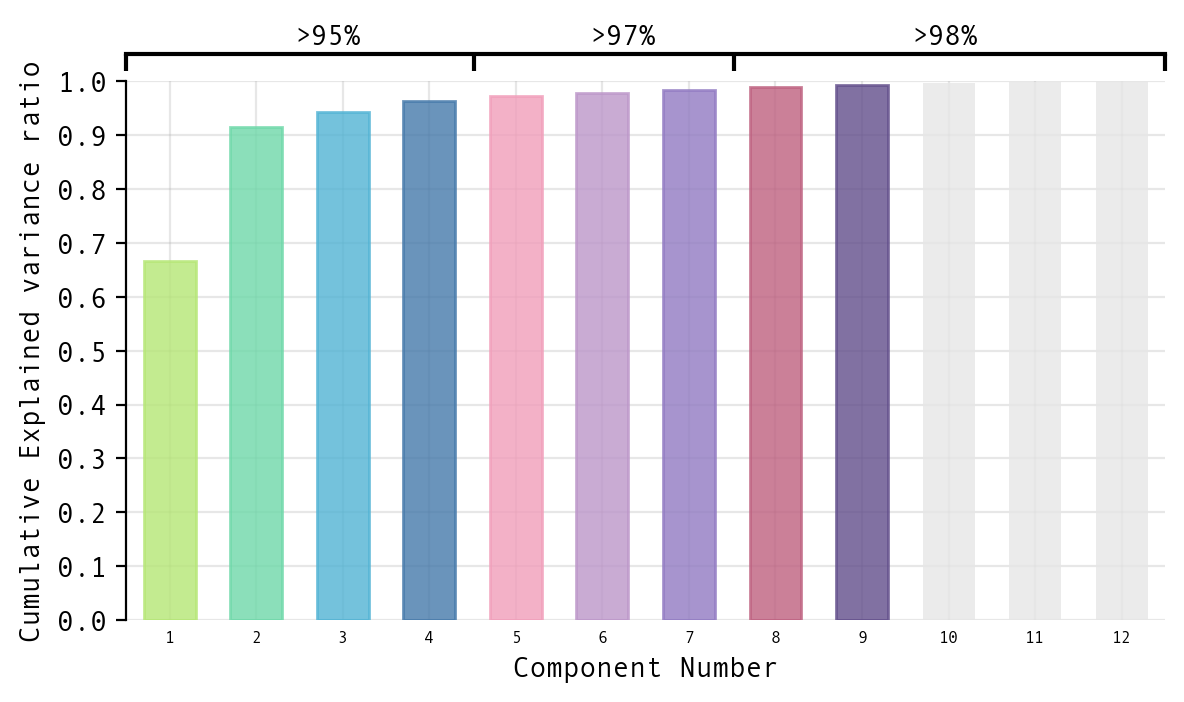

In [14]:
# Cumulative explained variance
cev = np.cumsum(pca.explained_variance_ratio_)
print("Cumulative Explained Variance:")
for i in range(12):
    print(f"  Mode 1-{i+1}: {cev[i]:.4f} ({cev[i]:.1%})")

# Plot
fig, ax = plot_explained(pca.explained_variance_ratio_, colour_before=9, annotate=True)
save_figure(fig, '../../figures/supplementary/S06_unilateral_variance.pdf')

In [6]:
# Individual and grouped mode variances (Supp §10.2)
individual_var = pca.explained_variance_ratio_
print("Individual Variance per Mode:")
for i in range(12):
    print(f"  Mode {i+1:2d}: {individual_var[i]:.4f} ({individual_var[i]:.2%})")

# Functional groupings (§10.2)
major_planform = individual_var[:4].sum()
local_incidence = individual_var[4] + individual_var[7]       # modes 5 & 8
hand_wing = individual_var[5] + individual_var[6] + individual_var[8]  # modes 6, 7, 9
noise = individual_var[9:].sum()                              # modes 10–12

print(f"\nFunctional Groupings:")
print(f"  Modes 1-4 (major planform):   {major_planform:.4f} ({major_planform:.2%})")
print(f"  Modes 5 & 8 (local incidence): {local_incidence:.4f} ({local_incidence:.2%})")
print(f"  Modes 6, 7, 9 (hand-wing):    {hand_wing:.4f} ({hand_wing:.2%})")
print(f"  Modes 10-12 (noise):           {noise:.4f} ({noise:.2%})")

Individual Variance per Mode:
  Mode  1: 0.6658 (66.58%)
  Mode  2: 0.2492 (24.92%)
  Mode  3: 0.0271 (2.71%)
  Mode  4: 0.0212 (2.12%)
  Mode  5: 0.0085 (0.85%)
  Mode  6: 0.0067 (0.67%)
  Mode  7: 0.0059 (0.59%)
  Mode  8: 0.0050 (0.50%)
  Mode  9: 0.0037 (0.37%)
  Mode 10: 0.0030 (0.30%)
  Mode 11: 0.0023 (0.23%)
  Mode 12: 0.0016 (0.16%)

Functional Groupings:
  Modes 1-4 (major planform):   0.9633 (96.33%)
  Modes 5 & 8 (local incidence): 0.0135 (1.35%)
  Modes 6, 7, 9 (hand-wing):    0.0163 (1.63%)
  Modes 10-12 (noise):           0.0069 (0.69%)


## Quantifying Total Variation

> **§6.2**

The cumulative explained variance shows that the first four modes capture most of the total variance, but it is also useful to quantify the *geometric volume* of the data cloud and how much it shrinks when projected onto the leading modes.

Each eigenvalue of the covariance matrix represents variance along one independent direction (mode). The product of all eigenvalues -- or equivalently, the determinant of the covariance matrix -- measures the total "volume" that the data occupy in the full-dimensional space. Taking the logarithm converts this multiplicative measure to an additive one: the **log-determinant**.

When the same data are projected into just the first four modes, the log-determinant drops dramatically, confirming that almost all variation lies along a small number of axes. A permutation test in which the coordinate columns were independently shuffled produces no instance of such a large drop, confirming that this concentration of variance is not an artefact of data scale or sampling but a genuine geometric property of the hawks' shape changes. 


> **See Notebook 06** for the full validation of this dimension reduction using tests with permutations, shuffled controls, etc.

In [7]:
from kinematic_morphospace.pca_core import get_PCA_input

# --- Mean Euclidean distance from mean shape ---
pca_input = get_PCA_input(unilateral_data[filt])
mean_shape = pca_input.mean(axis=0)
distances = np.linalg.norm(pca_input - mean_shape, axis=1)
print(f"Mean Euclidean distance from mean shape: {distances.mean():.3f} ± {distances.std():.3f} m")
print(f"  (normalised to maximum wingspan)")

# --- Log-determinant: full space vs 4-mode projection ---
cov_full = np.cov(pca_input, rowvar=False)
sign_full, logdet_full = np.linalg.slogdet(cov_full)
print(f"\nLog-determinant (full 12D): {logdet_full:.2f}")

# Project into the first 4 modes
scores_4 = scores[:len(pca_input), :4]  # training frames only
cov_4 = np.cov(scores_4[filt[:len(scores_4)]], rowvar=False) if scores_4.shape[0] >= pca_input.shape[0] else np.cov(pca.transform(pca_input)[:, :4], rowvar=False)
sign_4, logdet_4 = np.linalg.slogdet(cov_4)
print(f"Log-determinant (4-mode projection): {logdet_4:.2f}")
print(f"Reduction: {logdet_4 - logdet_full:.1f} log units")

# --- Permutation test ---
# Under H0 (columns independent), the variance concentration in the leading 4
# modes should be smaller.  We measure concentration as the log-det increase
# from full space to the 4-mode projection (positive = more concentrated).
n_perms = 2000 if PAPER_MODE else 200  # Full: 2000 (manuscript/supplementary)
rng = np.random.default_rng(42)
perm_drops = []

for i in range(n_perms):
    # Shuffle each column independently
    shuffled = pca_input.copy()
    for col in range(shuffled.shape[1]):
        rng.shuffle(shuffled[:, col])

    cov_shuf = np.cov(shuffled, rowvar=False)
    _, logdet_shuf_full = np.linalg.slogdet(cov_shuf)

    pca_shuf = PCA(n_components=4).fit(shuffled)
    scores_shuf = pca_shuf.transform(shuffled)
    cov_shuf_4 = np.cov(scores_shuf, rowvar=False)
    _, logdet_shuf_4 = np.linalg.slogdet(cov_shuf_4)

    perm_drops.append(logdet_shuf_4 - logdet_shuf_full)

perm_drops = np.array(perm_drops)
observed_drop = logdet_4 - logdet_full
p_value = np.mean(perm_drops >= observed_drop)

print(f"\nPermutation test ({n_perms} iterations):")
print(f"  Observed concentration: {observed_drop:.1f} log units")
print(f"  Shuffled concentration: {perm_drops.mean():.1f} ± {perm_drops.std():.1f}")
print(f"  p-value: {f'< 1/{n_perms}' if p_value == 0 else f'{p_value:.4f}'}")
print(f"\nConclusion: the concentration of variance in the first four modes is"
      f" {'genuine (p < 0.001)' if p_value < 0.001 else 'not significant'}.")

Mean Euclidean distance from mean shape: 0.237 ± 0.127 m
  (normalised to maximum wingspan)

Log-determinant (full 12D): -84.91
Log-determinant (4-mode projection): -19.82
Reduction: 65.1 log units

Permutation test (200 iterations):
  Observed concentration: 65.1 log units
  Shuffled concentration: 52.0 ± 0.0
  p-value: < 1/200

Conclusion: the concentration of variance in the first four modes is genuine (p < 0.001).


## Loadings and Component Interpretation (Preview)

The loadings matrix shows how each feather marker coordinate contributes to each morphing shape mode. The first four modes describe major planform shape changes:

| Mode | Variance | Description |
|------|----------|-------------|
| 1 | ~67% | Wing lifting / lowering (flapping axis) |
| 2 | ~25% | Wing spreading / folding |
| 3 | ~2% | Wing sweeping (forward/back) |
| 4 | ~2.1% | Tail spreading |

Modes 5–9 describe finer adjustments (incidence changes, hand-wing shape) with ~3% combined. Modes 10–12 are treated as noise (< 0.7% combined).

> **See Notebook 09** for the full mode-by-mode breakdown with functional categories, individual animations, and physical interpretation of each mode.

Saved: ../../figures/supplementary/S06_loadings_heatmap.pdf


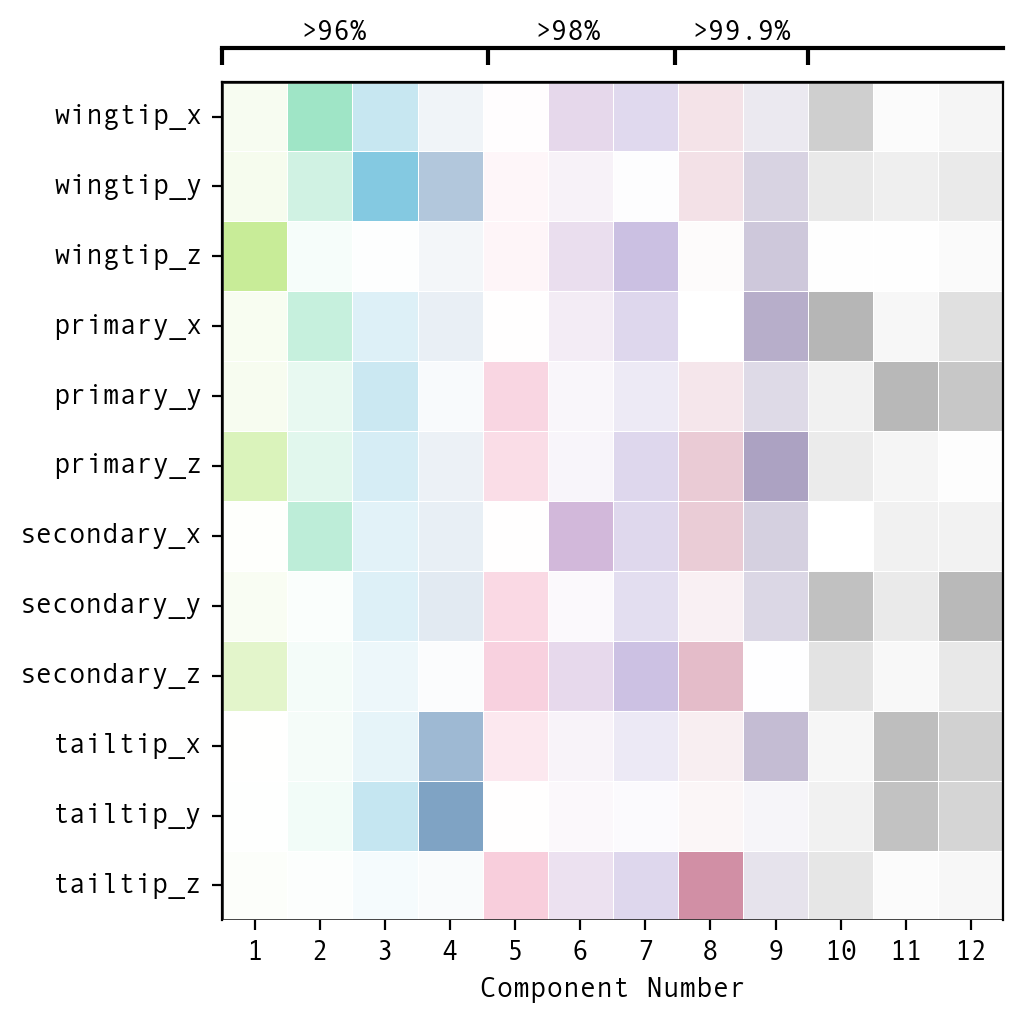

In [8]:
# Plot the loadings as a heatmap
# marker_names must include one entry per feature (4 markers × 3 axes = 12)
marker_labels = [f"{m}_{a}" for m in ["wingtip", "primary", "secondary", "tailtip"] for a in ["x", "y", "z"]]
fig, ax = plot_components_grid(principal_components, marker_names=marker_labels)
save_figure(fig, '../../figures/supplementary/S06_loadings_heatmap.pdf')

The darker colours show more contribution from that marker coordinate within each morphing shape mode. 

### Animated Mode Visualisation (Preview)

We can animate each morphing shape mode by creating animation frames for its score between ±2 standard deviations around the mean. This shows the physical shape change each mode encodes.

As with the bilateral PCA, individual modes do not represent realistic hawk shapes -- real flight configurations arise from combinations of multiple modes.

> **See Notebook 09** for systematic animations of all nine interpretable modes, reconstruction accuracy analysis, and evidence that realistic shapes require coordinated mode combinations.

In [9]:
# Animate a selected morphing shape mode
hawk3d = Animal3D('hawk', '../../data/mean_hawk_shape.csv')
mu = all_data_mean.reshape(1, -1, 3)
score_frames = get_score_range(scores, num_frames=25)

colour_list = ['#B5E675', '#6ED8A9', '#51B3D4',
               '#4579AA', '#BC96C9', '#917AC2',
               '#51B3D4', '#F19EBA', '#624E8B',
               '#888888', '#888888', '#888888']

# Reconstruct Mode 1 (wing lifting)
component_index = [0]
reconstructed = reconstruct(score_frames, principal_components, mu, component_index)

# Convert to bilateral for visualisation
recon_bilateral = to_bilateral(reconstructed)

# Interactive 3D animation
from morphing_birds import animate_plotly
slider_scores = score_frames[:, 0]
fig = animate_plotly(hawk3d, recon_bilateral, colour=colour_list[0],
                     score_vals=slider_scores)
fig.show()

## Cross-Bird Consistency (Preview)

We verify that the morphing shape modes generalise across individuals by running PCA per bird and comparing against the pooled components.

> **See Notebook 08** for the full individual-vs-shared analysis: principal cosine sweeps, plane-rotation analysis, permutation testing, leave-one-out cross-validation, and bootstrap stability.

Toothless data is consistent.
Toothless diagonal values are close to 1, same matrix.


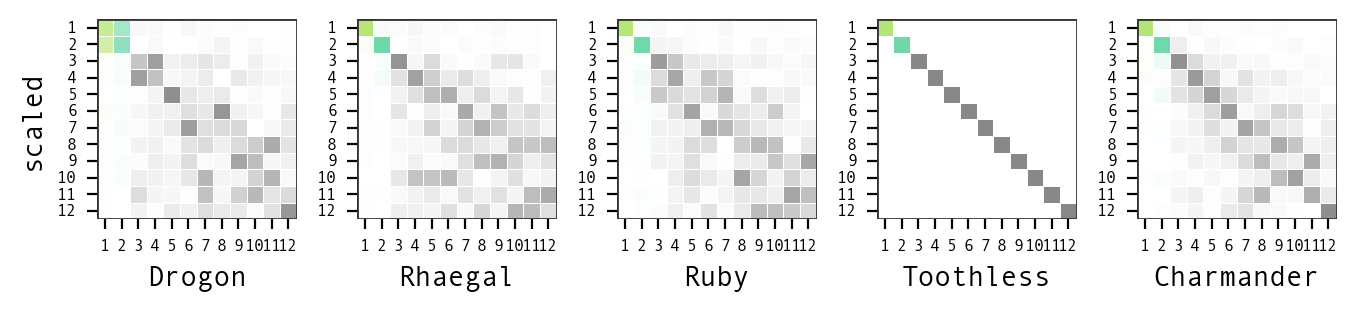

In [10]:
# Per-bird PCA comparison
filt = filter_by(unilateral_frame_info_df, obstacle=0)
principal_components, scores, pca = run_PCA(unilateral_data[filt], unilateral_data)
components_by_bird = run_PCA_birds(unilateral_data, unilateral_frame_info_df)

fig = compare_coeffs_hawks(
    components_by_bird['Toothless'], components_by_bird,
    colour_before=2, y_label='scaled'
)
plt.show(fig)

## Score Traces (Preview)

The morphing shape mode scores can be plotted against horizontal distance to perch, showing how wing–tail morphing evolves during a landing flight.

> **See Notebook 11** for the full time-trace analysis across individuals, distances, and flight conditions.

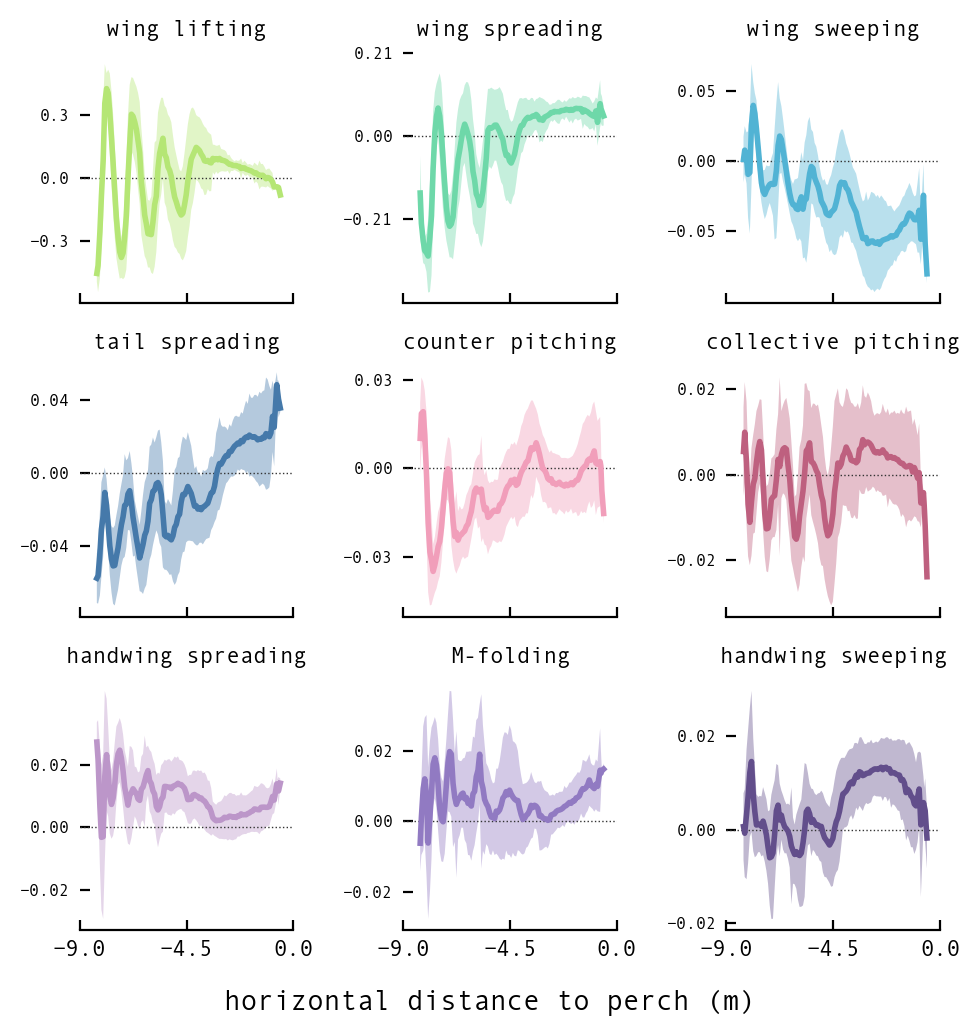

In [11]:
scores_df, horz_dist_bins = get_score_df(scores, unilateral_frame_info_df, size_bin=0.07)

# Negate PC07 (m-folding) for interpretability: positive = more folded
scores_df["PC07"] = -scores_df["PC07"]

# Save scores dataframe for later notebooks
scores_df.to_csv("../../data/unilateral/scores_binned.csv", index=False)

# Plot score traces for Toothless, 9 m, straight flights
plot_score_multi_PCs(scores_df, PC_num_list=range(1, 10),
                     perchDist=9, hawkname="Toothless",
                     turn="Straight", year=2020)
plt.show()

## Reconstructing Flight

We reconstruct a full bilateral flight from the unilateral scores, using four modes and independent left/right reconstructions. By comparing the 4-mode reconstruction against the original binned marker positions, we can visually assess how faithfully the leading modes capture real flight shapes.

In [12]:
# Select a flight: Toothless, 9 m, straight, 2020
flight = dict(hawkname="Toothless", perchDist="9m", turn="Straight", year=2020)

# Bin PCA scores per side (bins are identical — each bilateral frame contributes both sides)
_, left_scores, _, _ = get_binned_scores(scores_df, **flight, left=True)
_, right_scores, _, _ = get_binned_scores(scores_df, **flight, left=False)

# Reconstruct bilateral shape from the first 4 modes
mu = all_data_mean.reshape(1, -1, 3)
modes = [0, 1, 2, 3]
recon_bilateral = to_bilateral(
    reconstruct(right_scores.to_numpy(), principal_components, mu, modes),
    left=reconstruct(left_scores.to_numpy(), principal_components, mu, modes),
)

# Bin original bilateral markers by the same distance bins
n = len(combined_frame_info_df)
bilateral_mask = filter_by(scores_df.iloc[:n], **flight)
bins = scores_df.iloc[:n].loc[bilateral_mask, "bins"]
orig = transformed_markers[bilateral_mask, :8, :]  # exclude tailpack

orig_df = pd.DataFrame(orig.reshape(-1, 24), index=bins.index)
orig_df["bins"] = bins.values
orig_bilateral = (orig_df.groupby("bins", observed=True).mean()
                  .loc[left_scores.index]
                  .to_numpy().reshape(-1, 8, 3))

print(f"Reconstructed {len(left_scores)} distance bins using {len(modes)} modes")

Reconstructed 112 distance bins using 4 modes


In [13]:
# Animate: original (left) vs 4-mode reconstruction (right)
hawk3d = Animal3D('hawk', '../../data/mean_hawk_shape.csv')
animate_plotly_compare(hawk3d, [orig_bilateral, recon_bilateral])

## Summary

The morphing shape modes provide a compact, interpretable coordinate system for describing hawk wing–tail morphing in flight:

- **12 modes** capture 100% of unilateral marker variance.
- **4 modes** capture ~96.3% — the dominant planform shape changes.
- The modes **generalise across individuals**, providing a shared basis for comparison.
- Real flight shapes arise from **combinations** of multiple modes, not individual modes in isolation.

These modes are the foundation for all subsequent analysis: symmetry assessment (Notebook 10), score time traces (Notebook 11), clustering (Notebook 12), and cross-species generalisation (Notebook 14).

---

## References

- Björklund, M. (2019). Be careful with your principal components. *Evolution*, 73, 2151–2158.
- Wagner, G. P. (1984). On the eigenvalue distribution of genetic and phenotypic dispersion matrices. *Journal of Mathematical Biology*, 21, 77–95.
- Gleason, T. C. & Staelin, R. (1975). A proposal for handling missing data. *Psychometrika*, 40(2), 229–252.